In [5]:
import pandas as pd
import seaborn as sns
import numpy as np

In [6]:
df_cust=pd.read_csv("data/customers.csv")
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [7]:
df_cred=pd.read_csv("data/credit_profiles.csv")
df_cred.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [8]:
df_tran=pd.read_csv("data/transactions.csv")
df_tran.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [9]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


In [10]:
df_cust.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [11]:
df_cust[df_cust.annual_income.isna()]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,NaN,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,NaN,Single
97,98,Sia Batra,Male,47,Suburb,Business Owner,NaN,Married
102,103,Pooja Ganguly,Male,32,City,Data Scientist,NaN,Married
155,156,Krishna Trivedi,Male,24,City,Fullstack Developer,NaN,Married
170,171,Advait Kulkarni,Male,52,City,Business Owner,NaN,Single
186,187,Aanya Pande,Male,53,City,Consultant,NaN,Single
192,193,Mira Naidu,Male,37,Suburb,Data Scientist,NaN,Married
227,228,Mihika Batra,Male,48,City,Business Owner,NaN,Married
232,233,Aaditya Rathore,Male,26,City,Freelancer,NaN,Married


In [12]:
df_cust[df_cust.occupation=="Artist"].annual_income.median()

np.float64(45794.0)

In [13]:
# df_cust[df_cust.occupation=="Freelancer"].annual_income.median()
# df_cust[df_cust.occupation=="Business Owner"].annual_income.median()
# df_cust[df_cust.occupation=="Data Scientist	"].annual_income.median()
# df_cust[df_cust.occupation=="Fullstack Developer"].annual_income.median()
# df_cust[df_cust.occupation=="Consultant	"].annual_income.median()
occupation_wise_inc_median=df_cust.groupby("occupation")["annual_income"].median()
occupation_wise_inc_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [14]:
def get_median_val(row):
    if pd.isnull(row["annual_income"]):
        return occupation_wise_inc_mid(row["occupation"])
    else:
        return row["annual_income"]

In [15]:
df_cust["annual_income"]=df_cust.apply(
    lambda row:occupation_wise_inc_median[row["occupation"]] if pd.isnull(row["annual_income"]) else row["annual_income"],
    axis=1
)

In [16]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [17]:
df_cust.iloc[14]

cust_id                   15
name              Isha Arora
gender                Female
age                       25
location               Rural
occupation            Artist
annual_income        45794.0
marital_status       Married
Name: 14, dtype: object

In [18]:
import seaborn as sns
from matplotlib import pyplot as plt

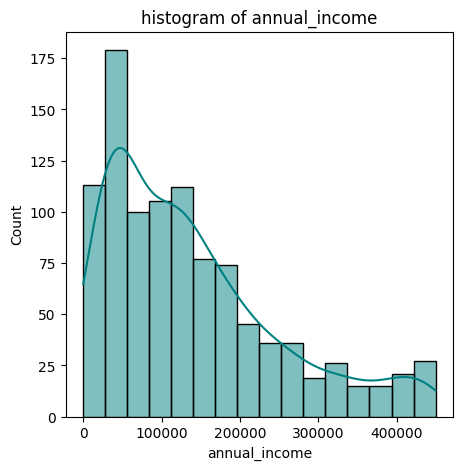

In [19]:
plt.figure(figsize=(5,5))
sns.histplot(df_cust['annual_income'],kde=True,color="teal",label="Data")
plt.title("histogram of annual_income")
plt.show()

In [20]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,138916.765500
std,288.819436,15.666155,110969.408643
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,48229.500000
50%,500.500000,32.000000,113416.000000
75%,750.250000,46.000000,192614.000000
max,1000.000000,135.000000,449346.000000


In [21]:
df_cust[df_cust["annual_income"]<100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,50.0,Married
262,263,Veer Rathod,Male,53,Suburb,Business Owner,50.0,Married
316,317,Avinash Chauhan,Male,47,City,Consultant,50.0,Married
333,334,Samaira D'Souza,Female,29,City,Data Scientist,50.0,Married
340,341,Ridhi Rastogi,Female,33,Rural,Fullstack Developer,50.0,Married
543,544,Gauri Gupta,Male,54,City,Consultant,2.0,Married
592,593,Vivaan Pande,Female,32,City,Business Owner,50.0,Married
633,634,Aradhya Pandey,Male,26,City,Data Scientist,2.0,Married
686,687,Gauri Nanda,Male,40,City,Business Owner,2.0,Married
696,697,Avani Lalwani,Male,47,City,Consultant,20.0,Married


In [22]:
for index,row in df_cust.iterrows():
    if row["annual_income"]<100:
        df_cust.at[index,"annual_income"]=occupation_wise_inc_median[row["occupation"]]

In [23]:
df_cust[df_cust["annual_income"]<100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [24]:
df_cust.loc[32]

cust_id                       33
name               Ritvik Bansal
gender                      Male
age                           32
location                    City
occupation        Data Scientist
annual_income           160219.0
marital_status           Married
Name: 32, dtype: object

In [25]:
avg_income_per_occupation=df_cust.groupby("occupation")["annual_income"].mean()
avg_income_per_occupation

occupation
Accountant              64123.562500
Artist                  45309.236842
Business Owner         268447.368512
Consultant              60703.154639
Data Scientist         137021.266304
Freelancer              76327.508772
Fullstack Developer     78727.972973
Name: annual_income, dtype: float64

In [26]:
avg_income_per_occupation.index

Index(['Accountant', 'Artist', 'Business Owner', 'Consultant',
       'Data Scientist', 'Freelancer', 'Fullstack Developer'],
      dtype='object', name='occupation')

In [27]:
avg_income_per_occupation.values

array([ 64123.5625    ,  45309.23684211, 268447.36851211,  60703.15463918,
       137021.26630435,  76327.50877193,  78727.97297297])

C:\Users\danis\AppData\Local\Temp\ipykernel_17760\1907766600.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_income_per_occupation.index,y=avg_income_per_occupation.values,palette="tab10")


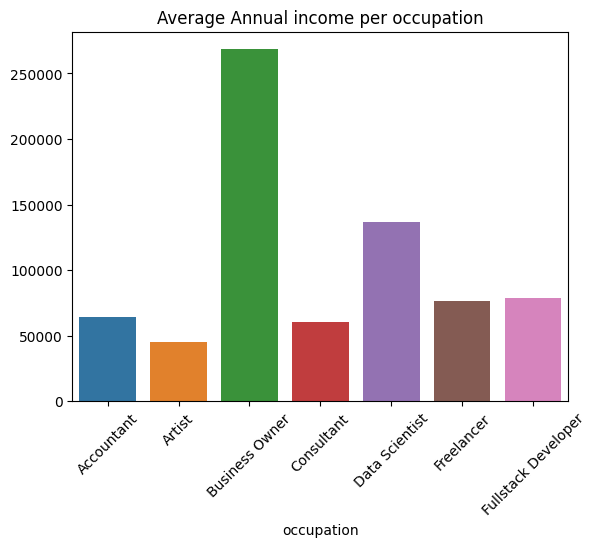

Text(0, 0.5, 'Averag Annual income($)')

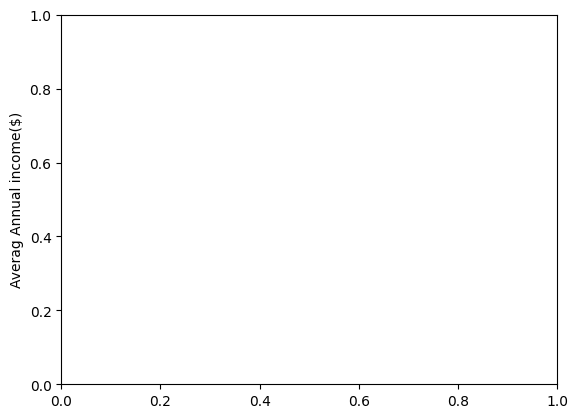

In [28]:
sns.barplot(x=avg_income_per_occupation.index,y=avg_income_per_occupation.values,palette="tab10")
plt.xticks(rotation=45)
plt.title("Average Annual income per occupation")
plt.xlabel("occupation")
plt.show()
plt.ylabel("Averag Annual income($)")

C:\Users\danis\AppData\Local\Temp\ipykernel_17760\122955841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_income_per_group.index,y=avg_income_per_group.values,palette="tab10")


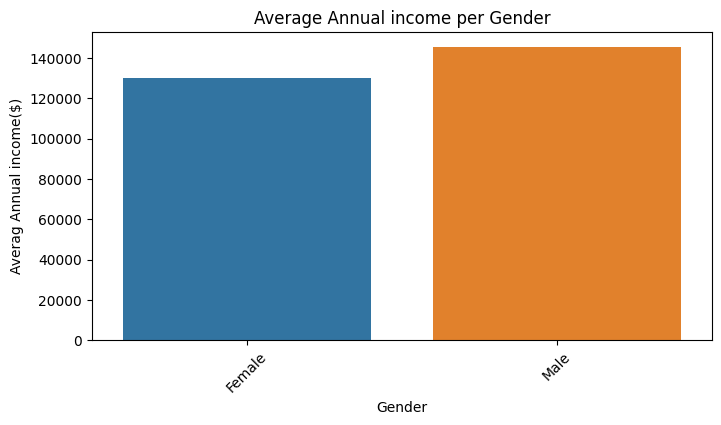

C:\Users\danis\AppData\Local\Temp\ipykernel_17760\122955841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_income_per_group.index,y=avg_income_per_group.values,palette="tab10")


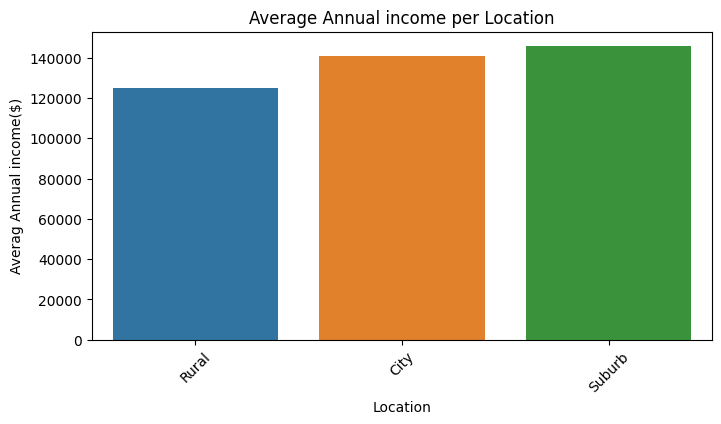

C:\Users\danis\AppData\Local\Temp\ipykernel_17760\122955841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_income_per_group.index,y=avg_income_per_group.values,palette="tab10")


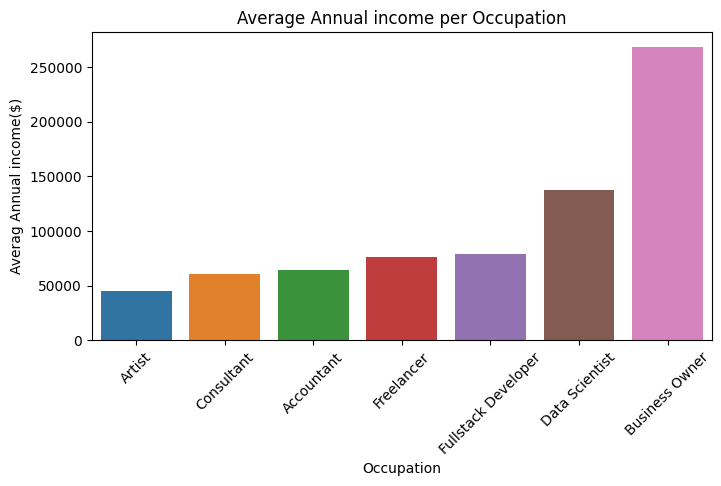

C:\Users\danis\AppData\Local\Temp\ipykernel_17760\122955841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_income_per_group.index,y=avg_income_per_group.values,palette="tab10")


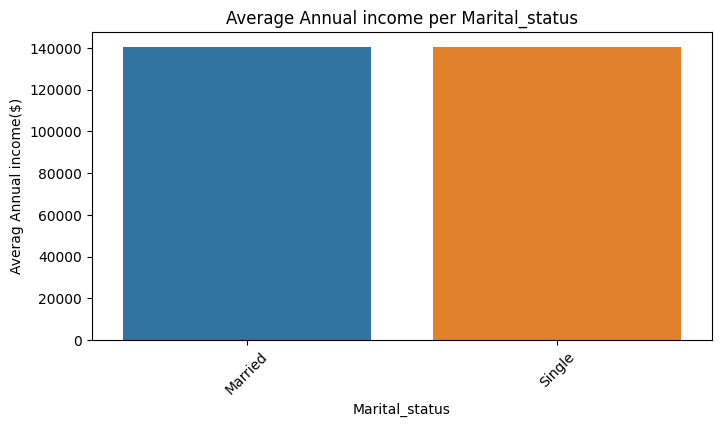

In [29]:
categorical_columns=['gender','location','occupation','marital_status']
for i in categorical_columns:
    plt.figure(figsize=(8,4))
    avg_income_per_group=df_cust.groupby(i)["annual_income"].mean().sort_values()
    sns.barplot(x=avg_income_per_group.index,y=avg_income_per_group.values,palette="tab10")
    plt.xticks(rotation=45)
    plt.title(f"Average Annual income per {i.capitalize()}")
    plt.xlabel(i.capitalize())
    plt.ylabel("Averag Annual income($)")
    plt.show()

In [30]:
df_cust.head(5)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [31]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [32]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,140483.548500
std,288.819436,15.666155,110463.002934
min,1.000000,1.000000,5175.000000
25%,250.750000,26.000000,49620.500000
50%,500.500000,32.000000,115328.000000
75%,750.250000,46.000000,195514.250000
max,1000.000000,135.000000,449346.000000


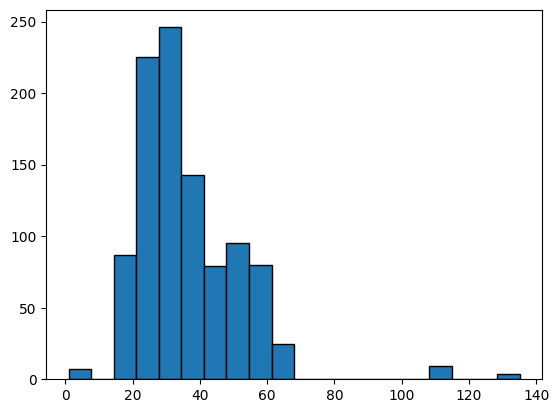

In [33]:
plt.hist(df_cust.age,bins=20,edgecolor="black")
plt.show()

In [34]:
outlier=df_cust[(df_cust.age<15)|(df_cust.age>80)]
outlier

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
41,42,Manya Thakur,Male,110,City,Artist,7621.0,Married
165,166,Swara Mehtani,Female,1,City,Freelancer,39721.0,Single
174,175,Sneha Jaiswal,Male,110,City,Freelancer,23723.0,Married
222,223,Aaryan Bajaj,Male,110,Suburb,Freelancer,210987.0,Married
277,278,Amaira Dewan,Male,110,City,Consultant,96522.0,Single
295,296,Veer Anand,Male,1,Rural,Accountant,55254.0,Married
325,326,Yash Chatterjee,Male,110,City,Accountant,61021.0,Single
610,611,Advait Mangal,Male,135,Rural,Business Owner,444776.0,Married
692,693,Aarohi Dubey,Male,1,City,Business Owner,83045.0,Married


In [35]:
median_age_per_occupation=df_cust.groupby("occupation")["age"].median()
median_age_per_occupation

occupation
Accountant             31.5
Artist                 26.0
Business Owner         51.0
Consultant             46.0
Data Scientist         32.0
Freelancer             24.0
Fullstack Developer    27.5
Name: age, dtype: float64

In [36]:
for index,row in outlier.iterrows():
    df_cust.at[index,"age"]=median_age_per_occupation[row["occupation"]]

C:\Users\danis\AppData\Local\Temp\ipykernel_17760\1747213097.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '31.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_cust.at[index,"age"]=median_age_per_occupation[row["occupation"]]


In [37]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,35.541500,140483.548500
std,288.819436,12.276634,110463.002934
min,1.000000,18.000000,5175.000000
25%,250.750000,26.000000,49620.500000
50%,500.500000,32.000000,115328.000000
75%,750.250000,44.250000,195514.250000
max,1000.000000,64.000000,449346.000000


In [38]:
bin_edges=[17,25,48,65]
bin_labels=['18-25','26-48','49-65']
df_cust['age_group']=pd.cut(df_cust['age'],bins=bin_edges,labels=bin_labels)
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49-65
1,2,Kabir Thakur,Female,47.0,City,Consultant,65172.0,Single,26-48
2,3,Kriti Mangal,Male,21.0,City,Freelancer,22378.0,Married,18-25
3,4,Sara Dwivedi,Male,24.0,Rural,Freelancer,33563.0,Married,18-25
4,5,Aarohi Negi,Male,48.0,City,Consultant,39406.0,Married,26-48


In [39]:
age_group_counts=df_cust.age_group.value_counts(normalize=True)*100
age_group_counts

age_group
26-48    56.7
18-25    24.6
49-65    18.7
Name: proportion, dtype: float64

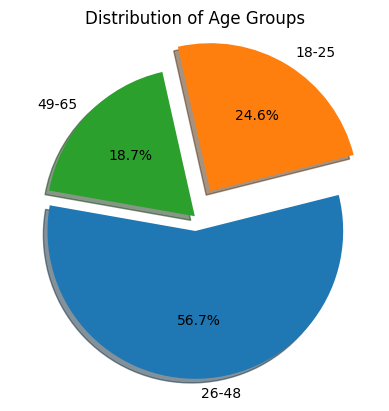

In [40]:
plt.pie(age_group_counts,labels=age_group_counts.index,autopct='%1.1f%%',shadow="True",explode=(0.1,0.2,0),startangle=170)
plt.title("Distribution of Age Groups")
plt.show()

In [41]:
df_cust.location.value_counts()

location
City      683
Suburb    232
Rural      85
Name: count, dtype: int64

In [42]:
df_cust.gender.value_counts()

gender
Male      674
Female    326
Name: count, dtype: int64

In [43]:
customer_location_gender=df_cust.groupby(['location','gender']).size().unstack()

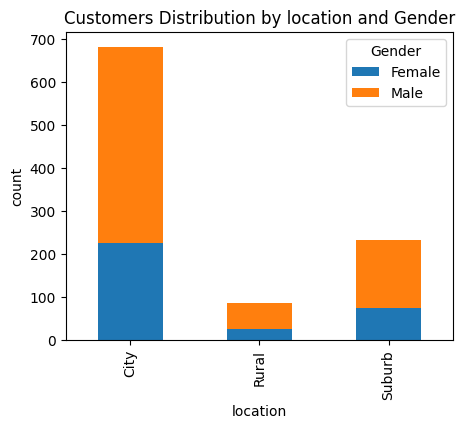

In [44]:
customer_location_gender.plot(kind="bar",stacked=True,figsize=(5,4))
plt.title("Customers Distribution by location and Gender")
plt.legend(title="Gender")
plt.xlabel("location")
plt.ylabel("count")
plt.show()

# Credit Score Table


In [45]:
df_cred.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [46]:
df_cred.shape

(1004, 6)

In [47]:
df_cred["cust_id"].nunique()

1000

In [48]:
df_cred[df_cred["cust_id"].duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
517,517,308,0.113860,33.0,3.0,500.0
569,569,344,NaN,NaN,NaN,NaN
570,569,344,0.112599,37.0,0.0,500.0
607,606,734,NaN,NaN,NaN,NaN
608,606,734,0.193418,4392.0,1.0,40000.0
664,662,442,NaN,NaN,NaN,NaN
665,662,442,0.856039,266.0,2.0,500.0


In [49]:
df_cred1=df_cred.drop_duplicates(subset="cust_id",keep="last")
df_cred1.shape

(1000, 6)

In [50]:
df_cred1[df_cred1["cust_id"].duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit


In [51]:
df_cred1.isnull().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 0
outstanding_debt                   0
credit_inquiries_last_6_months     0
credit_limit                      65
dtype: int64

In [52]:
df_cred1[df_cred1["credit_limit"].isnull()]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
10,11,679,0.557450,9187.0,2.0,NaN
35,36,790,0.112535,4261.0,1.0,NaN
37,38,514,0.296971,238.0,2.0,NaN
45,46,761,0.596041,24234.0,2.0,NaN
64,65,734,0.473715,13631.0,0.0,NaN
...,...,...,...,...,...,...
912,909,479,0.487555,320.0,3.0,NaN
931,928,311,0.832244,316.0,2.0,NaN
948,945,526,0.272734,227.0,1.0,NaN
954,951,513,0.175914,131.0,3.0,NaN


In [53]:
df_cred1.credit_limit.value_counts()

credit_limit
500.0      229
60000.0    186
40000.0    137
1500.0     100
1000.0      90
750.0       76
1250.0      75
20000.0     42
Name: count, dtype: int64

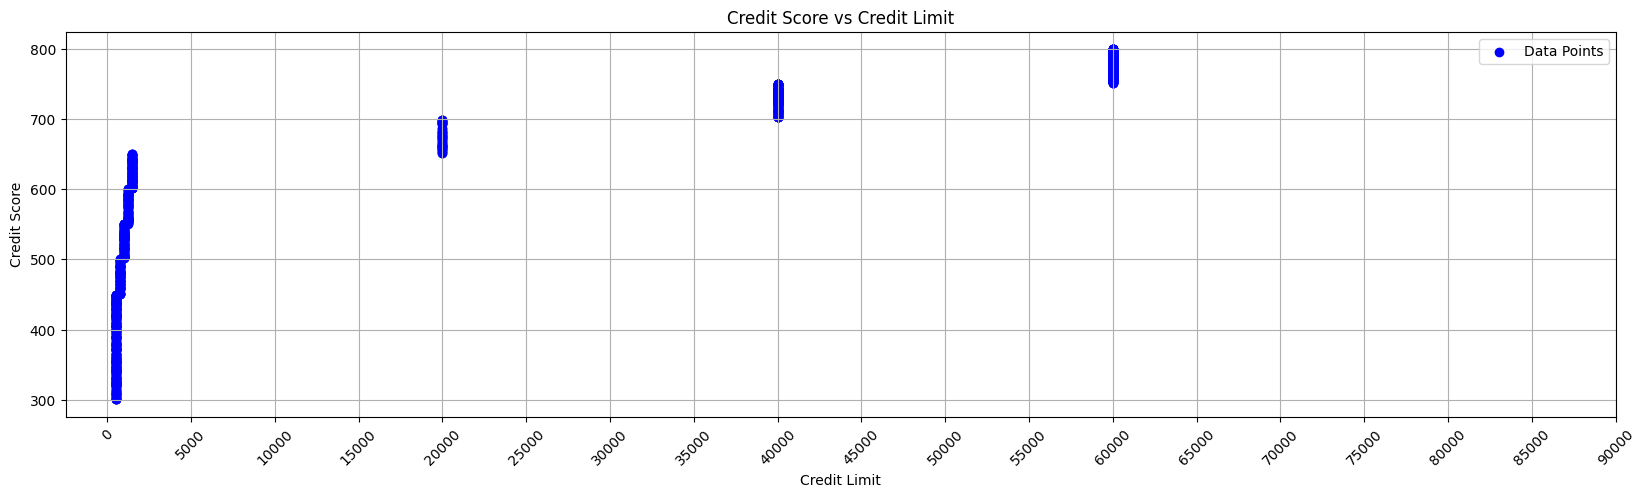

In [54]:

plt.figure(figsize=(20, 5))
plt.scatter(
    df_cred1['credit_limit'],
     df_cred1['credit_score'],
    c='blue',
    marker='o',
    label='Data Points'
)

plt.title('Credit Score vs Credit Limit')
plt.xlabel('Credit Limit')
plt.ylabel('Credit Score')

# Adjust x-axis tick interval
plt.xticks(range(0, 90001, 5000), rotation=45)

plt.grid(True)
plt.legend()

plt.show()

In [55]:
bin_ranges=[300,450,500,550,600,650,700,750,800]
bin_labels=[f"{start}-{end-1}"for start,end in zip(bin_ranges,bin_ranges[1:])]
df_cred1['credit_score_range']=pd.cut(df_cred1['credit_score'],bins=bin_ranges,labels=bin_labels,include_lowest=True,right=False)

C:\Users\danis\AppData\Local\Temp\ipykernel_17760\3859968939.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cred1['credit_score_range']=pd.cut(df_cred1['credit_score'],bins=bin_ranges,labels=bin_labels,include_lowest=True,right=False)


In [56]:
df_cred1.head(5)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,587,0.107928,161644.0,2.0,1250.0,550-599
2,3,544,0.854807,513.0,4.0,1000.0,500-549
3,4,504,0.336938,224.0,2.0,1000.0,500-549
4,5,708,0.586151,18090.0,2.0,40000.0,700-749


In [57]:
mode_df = df_cred1.groupby('credit_score_range')["credit_limit"] \
                  .agg(lambda x: x.mode().iloc[0]) \
                  .reset_index()

C:\Users\danis\AppData\Local\Temp\ipykernel_17760\3124395271.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mode_df = df_cred1.groupby('credit_score_range')["credit_limit"] \


In [58]:
df_cred1[df_cred1.credit_limit.isnull()].sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
931,928,311,0.832244,316.0,2.0,NaN,300-449
948,945,526,0.272734,227.0,1.0,NaN,500-549
258,259,427,0.339428,136.0,4.0,NaN,300-449


In [59]:
df_cred2= pd.merge(df_cred1,mode_df,on="credit_score_range",suffixes=("","_mode"))
df_cred2.sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
444,445,641,0.780326,983.0,4.0,1500.0,600-649,1500.0
579,580,390,0.150373,63.0,0.0,500.0,300-449,500.0
352,353,380,0.826193,222.0,3.0,500.0,300-449,500.0


In [60]:
df_cred2[df_cred2.credit_limit.isnull()].sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
140,141,520,0.210682,145.0,3.0,NaN,500-549,1000.0
725,726,737,0.136048,205404.0,4.0,NaN,700-749,40000.0
342,343,733,0.646581,20948.0,2.0,NaN,700-749,40000.0


In [61]:
df_cred3=df_cred2.copy()
df_cred3.credit_limit.fillna(df_cred3['credit_limit_mode'],inplace=True)
df_cred3

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0,550-599,1250.0
2,3,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0
...,...,...,...,...,...,...,...,...
995,996,564,0.702963,688.0,2.0,1250.0,550-599,1250.0
996,997,774,0.465462,17139.0,0.0,60000.0,750-799,60000.0
997,998,529,0.585856,386.0,3.0,1000.0,500-549,1000.0
998,999,725,0.249670,6973.0,2.0,40000.0,700-749,40000.0


In [62]:
df_cred3[df_cred3.credit_limit.isnull()].shape

(0, 8)

In [63]:
df_cred3.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,589.182000,0.498950,9683.597000,1.955000,19733.75000,19912.500000
std,288.819436,152.284929,0.233139,25255.893671,1.414559,24717.43818,24840.914633
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.00000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.00000,750.000000
50%,500.500000,601.500000,0.487422,550.000000,2.000000,1500.00000,1500.000000
75%,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.00000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.00000,60000.000000


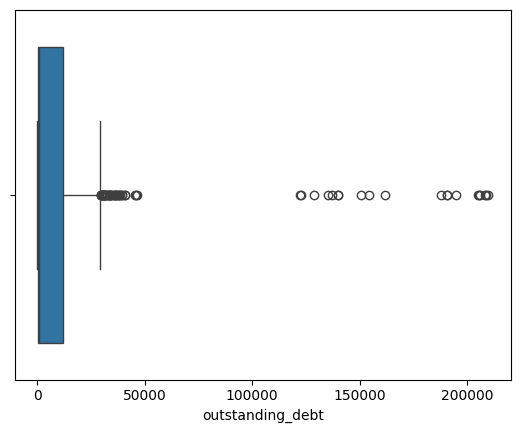

In [64]:
sns.boxplot(x=df_cred3.outstanding_debt)
plt.show()

In [65]:
df_cred3[df_cred3.outstanding_debt>df_cred3.credit_limit]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
1,2,587,0.107928,161644.0,2.0,1250.0,550-599,1250.0
19,20,647,0.439132,205014.0,3.0,1500.0,600-649,1500.0
25,26,758,0.250811,190838.0,2.0,60000.0,750-799,60000.0
38,39,734,0.573023,122758.0,3.0,40000.0,700-749,40000.0
93,94,737,0.739948,137058.0,2.0,40000.0,700-749,40000.0
204,205,303,0.364360,187849.0,0.0,500.0,300-449,500.0
271,272,703,0.446886,154568.0,1.0,40000.0,700-749,40000.0
301,302,722,0.608076,122402.0,4.0,40000.0,700-749,40000.0
330,331,799,0.363420,208898.0,4.0,60000.0,750-799,60000.0
350,351,320,0.285081,150860.0,0.0,500.0,300-449,500.0


In [66]:
df_cred3.loc[df_cred3.outstanding_debt>df_cred3.credit_limit,"outstanding_debt"]=df_cred3["credit_limit"]


In [67]:
df_cred3[df_cred3.outstanding_debt>df_cred3.credit_limit]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode


In [68]:
df_cred3.loc[1]

cust_id                                  2
credit_score                           587
credit_utilisation                0.107928
outstanding_debt                    1250.0
credit_inquiries_last_6_months         2.0
credit_limit                        1250.0
credit_score_range                 550-599
credit_limit_mode                   1250.0
Name: 1, dtype: object

In [69]:
df_cred3.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0
2,3,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0


In [70]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49-65
1,2,Kabir Thakur,Female,47.0,City,Consultant,65172.0,Single,26-48
2,3,Kriti Mangal,Male,21.0,City,Freelancer,22378.0,Married,18-25
3,4,Sara Dwivedi,Male,24.0,Rural,Freelancer,33563.0,Married,18-25
4,5,Aarohi Negi,Male,48.0,City,Consultant,39406.0,Married,26-48


In [71]:
df_merged=df_cust.merge(df_cred3,on="cust_id",how="inner")
df_merged

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,Kabir Thakur,Female,47.0,City,Consultant,65172.0,Single,26-48,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0
2,3,Kriti Mangal,Male,21.0,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,Sara Dwivedi,Male,24.0,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,Aarohi Negi,Male,48.0,City,Consultant,39406.0,Married,26-48,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Advait Rana,Female,26.0,City,Freelancer,46759.0,Married,26-48,564,0.702963,688.0,2.0,1250.0,550-599,1250.0
996,997,Sia Chatterjee,Male,55.0,City,Business Owner,290061.0,Single,49-65,774,0.465462,17139.0,0.0,60000.0,750-799,60000.0
997,998,Amara Tiwari,Male,29.0,City,Fullstack Developer,139141.0,Married,26-48,529,0.585856,386.0,3.0,1000.0,500-549,1000.0
998,999,Aanya Malhotra,Female,47.0,City,Business Owner,261191.5,Married,26-48,725,0.249670,6973.0,2.0,40000.0,700-749,40000.0


In [72]:
df_merged[["credit_score","outstanding_debt"]].corr()

,credit_score,outstanding_debt
credit_score,1.000000,0.680654
outstanding_debt,0.680654,1.000000


In [73]:
numerical_cols=["credit_score","credit_utilisation","outstanding_debt","credit_limit","annual_income"]
correlation_matrix=df_merged[numerical_cols].corr()
correlation_matrix

,credit_score,credit_utilisation,outstanding_debt,credit_limit,annual_income
credit_score,1.000000,-0.070445,0.680654,0.847952,0.575751
credit_utilisation,-0.070445,1.000000,0.192838,-0.080493,-0.086368
outstanding_debt,0.680654,0.192838,1.000000,0.810581,0.555661
credit_limit,0.847952,-0.080493,0.810581,1.000000,0.684775
annual_income,0.575751,-0.086368,0.555661,0.684775,1.000000


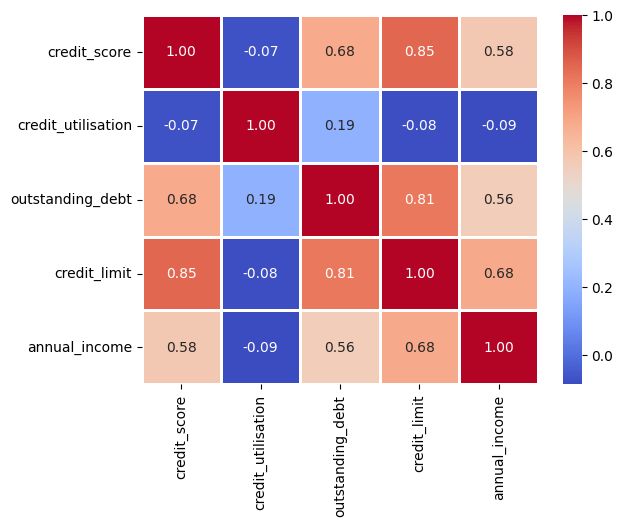

In [74]:
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=.8)
plt.show()

In [75]:
df_tran.head()


,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [76]:
df_tran.shape

(500000, 7)

In [77]:
df_tran.isnull().sum()

tran_id                0
cust_id                0
tran_date              0
tran_amount            0
platform            4941
product_category       0
payment_type           0
dtype: int64

In [78]:
df_tran[df_tran["platform"].isna()]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
355,356,58,2023-01-01,237,NaN,Electronics,Net Banking
418,419,383,2023-01-01,338,NaN,Electronics,Credit Card
607,608,421,2023-01-01,700,NaN,Electronics,Phonepe
844,845,945,2023-01-01,493,NaN,Sports,Credit Card
912,913,384,2023-01-01,85,NaN,Fashion & Apparel,Phonepe
...,...,...,...,...,...,...,...
499579,499580,924,2023-09-05,31,NaN,Fashion & Apparel,Gpay
499646,499647,944,2023-09-05,58445,NaN,Fashion & Apparel,Phonepe
499725,499726,620,2023-09-05,15,NaN,Sports,Net Banking
499833,499834,616,2023-09-05,97,NaN,Fashion & Apparel,Credit Card


In [79]:
df_tran.platform.value_counts()

platform
Amazon      151443
Flipkart    122660
Alibaba      73584
Meesho       73271
Shopify      39416
Cred         24741
Ebay          9944
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='product_category'>

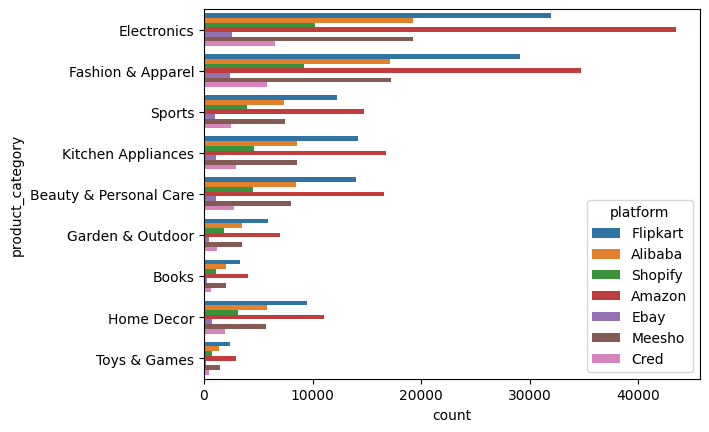

In [80]:
sns.countplot(y="product_category",hue="platform",data=df_tran)

In [81]:
df_tran.platform.mode()[0]

'Amazon'

In [82]:
df_tran.platform.fillna(df_tran.platform.mode()[0],inplace=True)

In [83]:
df_tran[df_tran["platform"].isna()]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type


In [84]:
df_tran.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711635,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


In [87]:
df_tran_zero=df_tran[df_tran["tran_amount"]==0]

In [88]:
df_tran.zero.head()

AttributeError: 'DataFrame' object has no attribute 'zero'

In [89]:
df_tran_zero[["platform","product_category","payment_type"]].value_counts()

platform  product_category  payment_type
Amazon    Electronics       Credit Card     4734
Name: count, dtype: int64

In [121]:
df_tran_1=df_tran[(df_tran.platform=="Amazon")&(df_tran.product_category=="Electronics")&(df_tran.payment_type=="Credit Card")]
df_tran_1.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
109,110,887,2023-01-01,635.000000,Amazon,Electronics,Credit Card
120,121,440,2023-01-01,554.000000,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,554.000000,Amazon,Electronics,Credit Card
173,174,676,2023-01-01,510.172685,Amazon,Electronics,Credit Card
190,191,763,2023-01-01,697.000000,Amazon,Electronics,Credit Card


In [91]:
median_to_replace=df_tran_1[df_tran_1.tran_amount>0].tran_amount.median()
median_to_replace

np.float64(554.0)

In [92]:
df_tran["tran_amount"].replace(0,median_to_replace,inplace=True)

In [93]:
df_tran.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,3230.452602
std,144337.711635,288.641924,13097.561071
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,66.000000
50%,250000.500000,502.000000,146.000000
75%,375000.250000,752.000000,413.000000
max,500000.000000,1000.000000,69999.000000


<Axes: xlabel='tran_amount', ylabel='Count'>

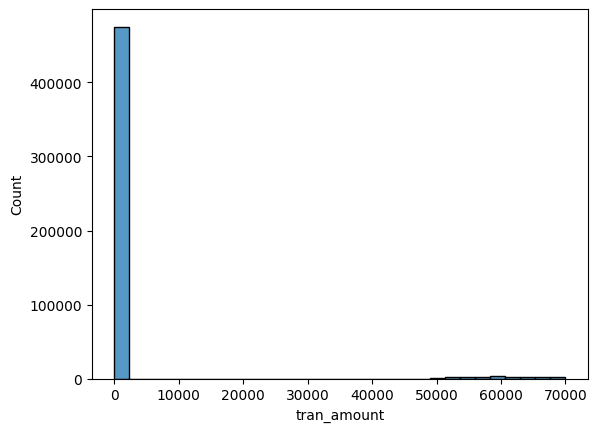

In [94]:
sns.histplot(df_tran.tran_amount,bins=30)

In [95]:
q1,q3=df_tran['tran_amount'].quantile([0.25,0.75])
iqr=q3-q1
lower=q1-2*iqr
upper=q3+2*iqr
lower,upper

(-628.0, 1107.0)

In [96]:
df_tran_outlier=df_tran[df_tran['tran_amount']>=upper]
df_tran_outlier

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,55131,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,59679,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,60184,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,54678,Meesho,Sports,Gpay


In [97]:
df_tran_normal=df_tran[df_tran.tran_amount<upper]
df_tran_normal.shape

(475000, 7)

In [98]:
tran_mean_category=df_tran_normal.groupby("product_category")["tran_amount"].mean()
tran_mean_category

product_category
Beauty & Personal Care     92.167205
Books                      29.553515
Electronics               510.172685
Fashion & Apparel          64.553463
Garden & Outdoor          125.630277
Home Decor                302.487561
Kitchen Appliances        176.773288
Sports                    269.181631
Toys & Games               50.333298
Name: tran_amount, dtype: float64

In [99]:
df_tran.loc[df_tran_outlier.index,'tran_amount']=df_tran_outlier['product_category'].map(tran_mean_category)

C:\Users\danis\AppData\Local\Temp\ipykernel_17760\1492800818.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 92.16720517  50.33329759 176.77328782 ... 269.18163136 269.18163136
  64.55346325]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_tran.loc[df_tran_outlier.index,'tran_amount']=df_tran_outlier['product_category'].map(tran_mean_category)


In [100]:
df_tran.loc[df_tran_outlier.index]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,92.167205,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,50.333298,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,176.773288,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,64.553463,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,176.773288,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,64.553463,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,64.553463,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,269.181631,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,269.181631,Meesho,Sports,Gpay


<Axes: xlabel='tran_amount', ylabel='Count'>

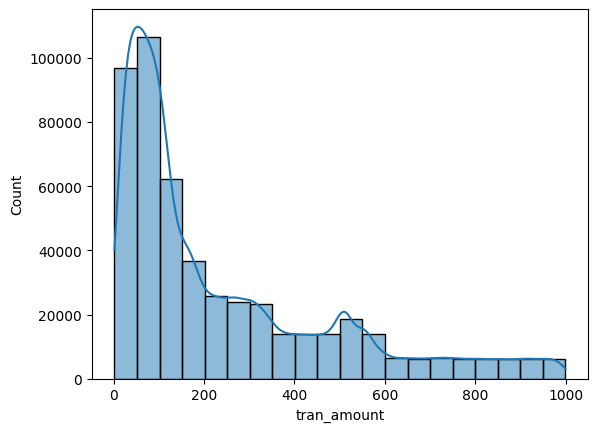

In [101]:
sns.histplot(df_tran.tran_amount,kde=True,bins=20)

<Axes: xlabel='payment_type', ylabel='percent'>

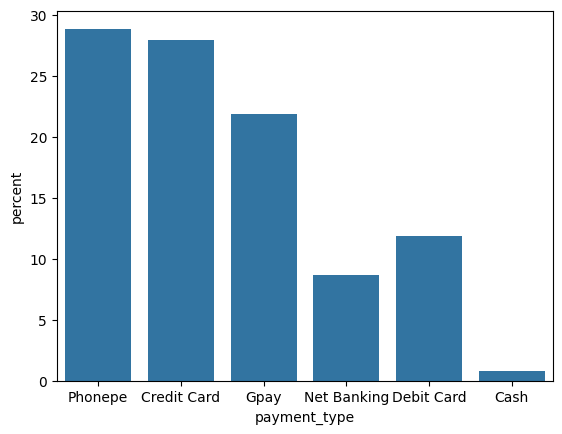

In [102]:
sns.countplot(x=df_tran.payment_type,stat='percent')

In [103]:
df_merged_2=pd.merge(df_merged,df_tran,on="cust_id",how="inner")
df_merged_2.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,...,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode,tran_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-749,40000.0,1283,2023-01-01,30.0,Shopify,Fashion & Apparel,Net Banking
1,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-749,40000.0,1382,2023-01-01,96.0,Amazon,Sports,Debit Card
2,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-749,40000.0,1521,2023-01-01,86.0,Meesho,Garden & Outdoor,Gpay
3,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-749,40000.0,1576,2023-01-01,149.0,Amazon,Beauty & Personal Care,Phonepe
4,1,Dhruv Bansal,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-749,40000.0,1757,2023-01-01,37.0,Flipkart,Fashion & Apparel,Credit Card


<Axes: xlabel='age_group', ylabel='count'>

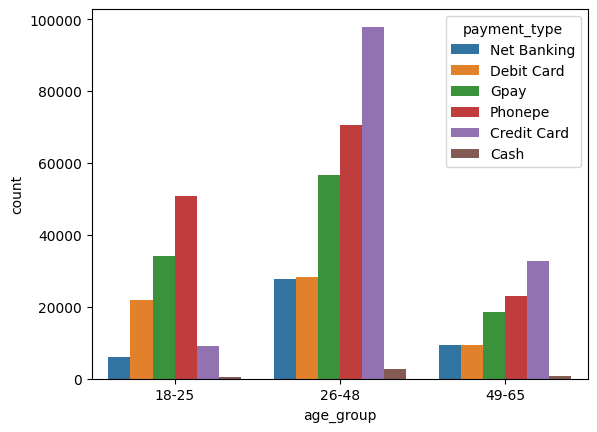

In [104]:
sns.countplot(x="age_group",hue="payment_type",data=df_merged_2)

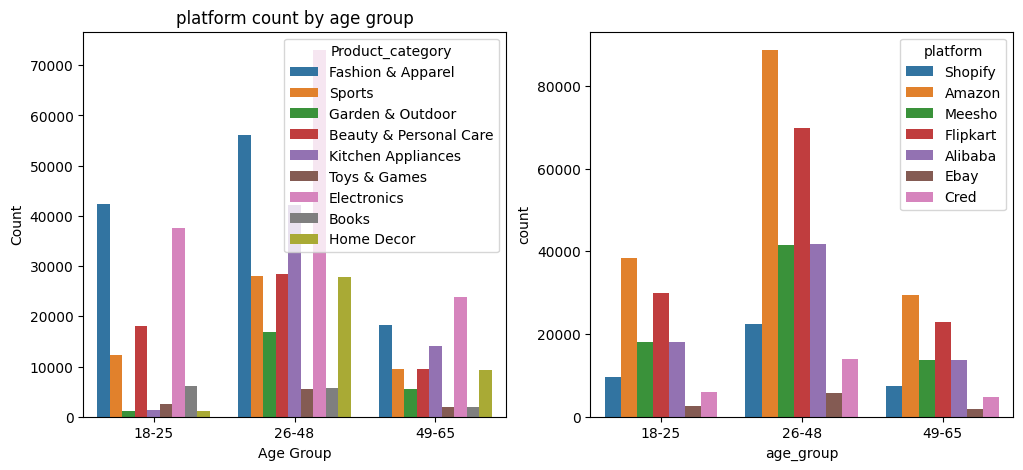

In [105]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
sns.countplot(x='age_group',hue='product_category',data=df_merged_2,ax=ax1)
ax1.set_title("product category count by age group")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Count")
ax1.legend(title='Product_category',loc='upper right')

sns.countplot(x='age_group',hue='platform',data=df_merged_2,ax=ax2)
ax1.set_title("platform count by age group")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Count")
ax2.legend(title='platform',loc='upper right')

plt.show()

In [106]:
# Group the data by age group and calculate the average credit_limit and credit_score
age_group_metrics = df_merged.groupby('age_group')[['annual_income', 'credit_limit', 'credit_score']].mean().reset_index()
age_group_metrics

C:\Users\danis\AppData\Local\Temp\ipykernel_17760\3918136653.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_metrics = df_merged.groupby('age_group')[['annual_income', 'credit_limit', 'credit_score']].mean().reset_index()


,age_group,annual_income,credit_limit,credit_score
0,18-25,37091.235772,1130.081301,484.451220
1,26-48,145869.623457,20560.846561,597.569665
2,49-65,260165.925134,41699.197861,701.524064


C:\Users\danis\AppData\Local\Temp\ipykernel_17760\2606875490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='annual_income', data=age_group_metrics, palette='tab10', ax=ax1)
C:\Users\danis\AppData\Local\Temp\ipykernel_17760\2606875490.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='credit_limit', data=age_group_metrics, palette='hls', ax=ax2)
C:\Users\danis\AppData\Local\Temp\ipykernel_17760\2606875490.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='credit_score', data=age_g

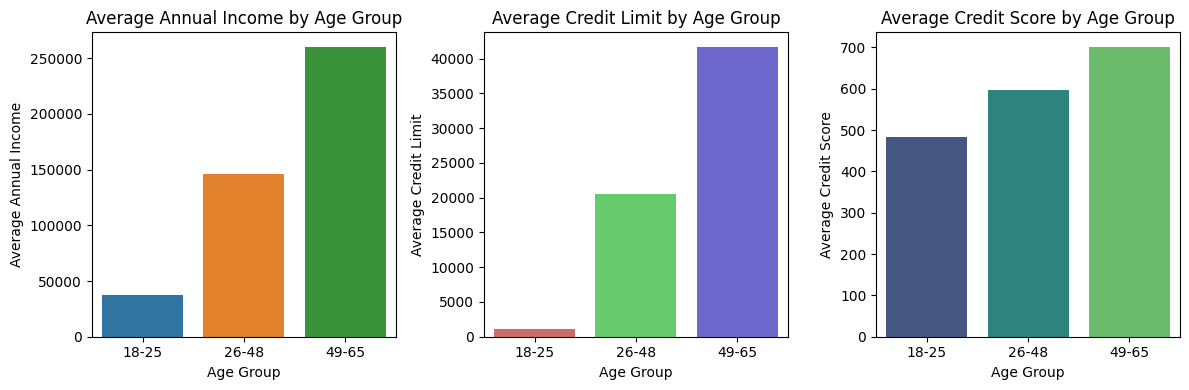

In [107]:
# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

# Plot 1: Average annual income by age group
sns.barplot(x='age_group', y='annual_income', data=age_group_metrics, palette='tab10', ax=ax1)
ax1.set_title('Average Annual Income by Age Group')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Annual Income')
ax1.tick_params(axis='x', rotation=0)

# Plot 2: Average Max Credit Limit by Age Group
sns.barplot(x='age_group', y='credit_limit', data=age_group_metrics, palette='hls', ax=ax2)
ax2.set_title('Average Credit Limit by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Average Credit Limit')
ax2.tick_params(axis='x', rotation=0)

# Plot 3: Average Credit Score by Age Group
sns.barplot(x='age_group', y='credit_score', data=age_group_metrics, palette='viridis', ax=ax3)
ax3.set_title('Average Credit Score by Age Group')
ax3.set_xlabel('Age Group')
ax3.set_ylabel('Average Credit Score')
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Business Analysis and launch of AB testing: Targeting Untapped Market

### Insights specific to customers with age group of 18 - 25
1. People with age group of 18 -25 accounts to ~25% of customer base in the data
2. Avg annual income of this age group is less than 50k
3. They don't have much credit history which is getting reflected in their credit score and max credit limit 
4. Usage of credit cards as payment type is relatively low compared to other groups
5. Avg transaction amount made with credit cards is also low compared to other groups
5. Top 3 most used shopping products categories  : Electronics, Fashion & Apparel, Beauty & Personal care

In [108]:
alpha=0.05
power=0.8
effect_size=0.2 # mean and standard dev of both 
import statsmodels.stats.api as sms
sms.tt_ind_solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1,
    alternative="two-sided"
)

393.4056930002526

In [109]:
# Calculate the required sample size for different effect sizes
effect_sizes = [0.1, 0.2, 0.3, 0.4, 0.5,1]  #  standard deviations greater than control group 

for effect_size in effect_sizes:
    sample_size = sms.tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, ratio=1, alternative='two-sided')
    print(f"Effect Size: {effect_size}, Required Sample Size: {int(sample_size)} customers")

Effect Size: 0.1, Required Sample Size: 1570 customers
Effect Size: 0.2, Required Sample Size: 393 customers
Effect Size: 0.3, Required Sample Size: 175 customers
Effect Size: 0.4, Required Sample Size: 99 customers
Effect Size: 0.5, Required Sample Size: 63 customers
Effect Size: 1, Required Sample Size: 16 customers


In [110]:
df = pd.read_csv('data/avg_transactions_after_campaign.csv')
df.head(4)

,campaign_date,control_group_avg_tran,test_group_avg_tran
0,2023-09-10,251.02,401.78
1,2023-09-11,250.77,326.16
2,2023-09-12,248.81,303.92
3,2023-09-13,255.90,363.29


In [111]:
df.shape

(62, 3)

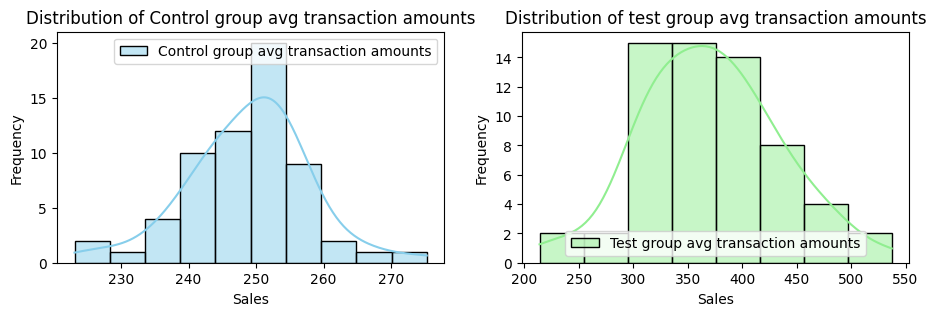

In [112]:
# Let's look at distributions of avg transactions amounts in both groups
# Create a 1x2 grid of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))

# Plot the distribution of Campaign A Sales
sns.histplot(df['control_group_avg_tran'], kde=True, color='skyblue', label='Control group avg transaction amounts', ax=ax1)
ax1.set_xlabel('Sales')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Control group avg transaction amounts')
ax1.legend()

# Plot the distribution of Campaign B Sales
sns.histplot(df['test_group_avg_tran'], kde=True, color='lightgreen', label='Test group avg transaction amounts', ax=ax2)
ax2.set_xlabel('Sales')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of test group avg transaction amounts')
ax2.legend()

# Show the plots
plt.show()

In [113]:
df[df["control_group_avg_tran"]>df["test_group_avg_tran"]].shape[0]/df.shape[0]


0.03225806451612903

In [114]:
control_mean = df["control_group_avg_tran"].mean().round(2)
control_std = df["control_group_avg_tran"].std().round(2)
control_mean, control_std

(np.float64(248.94), np.float64(9.14))

In [115]:
test_mean = df["test_group_avg_tran"].mean().round(2)
test_std = df["test_group_avg_tran"].std().round(2)
test_mean, test_std

(np.float64(370.54), np.float64(63.25))

In [116]:
sample_size = df.shape[0]
sample_size

62

In [117]:
a = (control_std**2/sample_size)
b = (test_std**2/sample_size)

Z_score = (test_mean-control_mean)/np.sqrt(a+b)
Z_score

np.float64(14.982390916086468)

In [118]:
from scipy import stats as st
# For a significance level of 5% (0.05) in a right-tailed test, the critical Z-value is approximately 1.645
critical_z_value = st.norm.ppf(1 - alpha)  # Right-tailed test at 5% significance level
critical_z_value

np.float64(1.6448536269514722)

In [119]:
(Z_score > critical_z_value)

np.True_

Since Z score is higher than critical Z value, we can reject the null hypothesis.

In [120]:
test_group_ci=st.norm.interval(0.95,loc=test_mean,scale=test_std/np.sqrt(sample_size))
test_group_ci

(np.float64(354.7960835592616), np.float64(386.28391644073844))

### - so by this we can conclude the credit range can assign from (354 to 386) for youth